
# Stock Market Price Movement Prediction

## Project Objective
This notebook follows the certification task requirements by building a complete predictive modeling workflow:
- data collection and exploration
- data cleaning and transformation
- exploratory data analysis
- feature selection
- model development and evaluation
- cross-validation and hyperparameter tuning
- model saving for deployment
- Streamlit deployment instructions

The project predicts whether a stock will move **UP** or **DOWN** on the next trading day using Yahoo Finance price data, technical indicators, and encoded categorical features.



## Dataset Description

The dataset is built directly from Yahoo Finance for a basket of large-cap US stocks. Each row represents one trading day for one ticker, and the target is created from the next day's closing price.

Raw columns:
- Date
- Open
- High
- Low
- Close
- Volume
- Ticker

Engineered features include:
- moving averages
- RSI
- MACD
- Bollinger Bands
- momentum and volatility indicators
- one-hot encoded categorical features for `Ticker` and `Day_Of_Week`


In [1]:
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
plt.rcParams['figure.figsize'] = (14, 6)

tickers = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "META",
    "NVDA",
    "TSLA",
    "JPM",
    "V",
    "JNJ",
]

print('Training universe:', ', '.join(tickers))

Training universe: AAPL, MSFT, GOOGL, AMZN, META, NVDA, TSLA, JPM, V, JNJ


In [2]:
"""
Shared pipeline utilities for the stock movement prediction project.
"""

from __future__ import annotations

from datetime import datetime, timedelta
from pathlib import Path
from typing import Iterable

import joblib
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_validate, TimeSeriesSplit
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

BASE_DIR = Path.cwd()
MODEL_PATH = BASE_DIR / "stock_prediction_model.pkl"
SCALER_PATH = BASE_DIR / "scaler.pkl"
FEATURE_NAMES_PATH = BASE_DIR / "feature_names.txt"
MODEL_INFO_PATH = BASE_DIR / "model_info.pkl"

DEFAULT_TRAIN_TICKERS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "META",
    "NVDA",
    "TSLA",
    "JPM",
    "V",
    "JNJ",
]
REQUIRED_PRICE_COLUMNS = ["Date", "Open", "High", "Low", "Close", "Volume"]
NON_FEATURE_COLUMNS = {"Date", "Target", "Open", "High", "Low", "Close", "Adj_Close"}


def normalize_downloaded_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Flatten yfinance output into a predictable single-level schema."""
    cleaned = df.copy()

    if isinstance(cleaned.columns, pd.MultiIndex):
        cleaned.columns = [str(col[0]).strip() for col in cleaned.columns.to_flat_index()]
    else:
        cleaned.columns = [str(col).strip() for col in cleaned.columns]

    return cleaned.rename(columns={"Adj Close": "Adj_Close", "Date_": "Date"})


def download_stock_data(ticker: str, lookback_days: int = 365 * 3) -> pd.DataFrame:
    """Download one ticker's historical data from Yahoo Finance."""
    end_date = datetime.now()
    start_date = end_date - timedelta(days=lookback_days)
    stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)

    if stock_data.empty:
        raise ValueError(f"Could not fetch data for ticker '{ticker}'.")

    stock_data = normalize_downloaded_columns(stock_data.reset_index())
    missing_columns = [col for col in REQUIRED_PRICE_COLUMNS if col not in stock_data.columns]

    if missing_columns:
        raise ValueError(
            f"Downloaded data for '{ticker}' is missing expected columns: {', '.join(missing_columns)}"
        )

    stock_data["Ticker"] = ticker
    return stock_data


def build_stock_universe(tickers: Iterable[str], lookback_days: int = 365 * 3) -> pd.DataFrame:
    """Download and concatenate multiple stock histories."""
    frames = [download_stock_data(ticker, lookback_days=lookback_days) for ticker in tickers]
    combined = pd.concat(frames, ignore_index=True)
    combined["Date"] = pd.to_datetime(combined["Date"])
    return combined.sort_values(["Date", "Ticker"]).reset_index(drop=True)


def clean_stock_data(df: pd.DataFrame) -> pd.DataFrame:
    """Sort, deduplicate, and fill price data."""
    data = normalize_downloaded_columns(df).copy()
    data["Date"] = pd.to_datetime(data["Date"])
    data = data.sort_values(["Ticker", "Date"]).drop_duplicates(subset=["Ticker", "Date"]).reset_index(drop=True)

    for column in ["Open", "High", "Low", "Close", "Volume"]:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    data[["Open", "High", "Low", "Close", "Volume"]] = (
        data.groupby("Ticker")[["Open", "High", "Low", "Close", "Volume"]].transform(lambda s: s.ffill().bfill())
    )
    return data


def _calculate_indicators_for_ticker(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame.sort_values("Date").copy()

    data["Daily_Return"] = data["Close"].pct_change() * 100
    data["MA_5"] = data["Close"].rolling(window=5).mean()
    data["MA_10"] = data["Close"].rolling(window=10).mean()
    data["MA_20"] = data["Close"].rolling(window=20).mean()
    data["MA_50"] = data["Close"].rolling(window=50).mean()
    data["EMA_12"] = data["Close"].ewm(span=12, adjust=False).mean()
    data["EMA_26"] = data["Close"].ewm(span=26, adjust=False).mean()
    data["MACD"] = data["EMA_12"] - data["EMA_26"]
    data["MACD_Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()

    delta = data["Close"].diff()
    gain = delta.clip(lower=0).rolling(window=14).mean()
    loss = (-delta.clip(upper=0)).rolling(window=14).mean()
    rs = gain / loss.replace(0, np.nan)
    data["RSI"] = 100 - (100 / (1 + rs))
    data.loc[(loss == 0) & (gain > 0), "RSI"] = 100
    data.loc[(loss == 0) & (gain == 0), "RSI"] = 50

    data["BB_Middle"] = data["Close"].rolling(window=20).mean()
    bb_std = data["Close"].rolling(window=20).std()
    data["BB_Upper"] = data["BB_Middle"] + (bb_std * 2)
    data["BB_Lower"] = data["BB_Middle"] - (bb_std * 2)
    data["BB_Width"] = (data["BB_Upper"] - data["BB_Lower"]) / data["BB_Middle"]

    data["Volume_MA_10"] = data["Volume"].rolling(window=10).mean()
    data["Volume_Ratio"] = data["Volume"] / data["Volume_MA_10"]
    data["Momentum_5"] = data["Close"] - data["Close"].shift(5)
    data["Momentum_10"] = data["Close"] - data["Close"].shift(10)
    data["Volatility_10"] = data["Daily_Return"].rolling(window=10).std()
    data["Volatility_20"] = data["Daily_Return"].rolling(window=20).std()
    data["HL_Spread"] = (data["High"] - data["Low"]) / data["Close"] * 100
    data["Price_Range"] = (data["High"] - data["Low"]) / data["Open"] * 100
    data["Gap_Open"] = (data["Open"] - data["Close"].shift(1)) / data["Close"].shift(1) * 100
    data["Day_Of_Week"] = data["Date"].dt.day_name()

    return data.replace([np.inf, -np.inf], np.nan)


def calculate_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Add technical and calendar features to each ticker's price history."""
    cleaned = clean_stock_data(df)
    frames = [_calculate_indicators_for_ticker(frame) for _, frame in cleaned.groupby("Ticker", sort=False)]
    return pd.concat(frames, ignore_index=True).sort_values(["Date", "Ticker"]).reset_index(drop=True)


def add_target_column(df: pd.DataFrame) -> pd.DataFrame:
    """Create the next-day movement target for each ticker."""
    data = df.copy()
    future_close = data.groupby("Ticker")["Close"].shift(-1)
    data["Target"] = (future_close > data["Close"]).astype(int)
    data = data.loc[future_close.notna()].copy()
    return data.reset_index(drop=True)


def detect_outliers_zscore(df: pd.DataFrame, numeric_cols: list[str], threshold: float = 3.0) -> pd.Series:
    """Count outliers per numeric column using z-scores."""
    if not numeric_cols:
        return pd.Series(dtype=int)

    z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy="omit"))
    z_scores = np.atleast_2d(z_scores)
    counts = np.atleast_1d((z_scores > threshold).sum(axis=0))
    return pd.Series(counts, index=numeric_cols, dtype=int).sort_values(ascending=False)


def cap_outliers_iqr(df: pd.DataFrame, numeric_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Cap numeric columns using the IQR rule."""
    capped = df.copy()
    bounds = {}

    for col in numeric_cols:
        q1 = capped[col].quantile(0.25)
        q3 = capped[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        capped[col] = capped[col].clip(lower_bound, upper_bound)
        bounds[col] = {
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
        }

    return capped, pd.DataFrame(bounds).T


def encode_categorical_features(df: pd.DataFrame, categorical_cols: list[str] | None = None) -> pd.DataFrame:
    """One-hot encode categorical columns."""
    categorical_cols = categorical_cols or ["Ticker", "Day_Of_Week"]
    present_cols = [col for col in categorical_cols if col in df.columns]
    if not present_cols:
        return df.copy()
    return pd.get_dummies(df, columns=present_cols, drop_first=False, dtype=int)


def get_feature_columns(df: pd.DataFrame) -> list[str]:
    """Return the candidate feature columns."""
    return [col for col in df.columns if col not in NON_FEATURE_COLUMNS]


def select_features(
    df: pd.DataFrame,
    target_col: str = "Target",
    max_features: int = 18,
    importance_threshold: float = 0.03,
    corr_threshold: float = 0.90,
) -> tuple[list[str], pd.DataFrame, list[str]]:
    """Select relevant features using importance ranking and correlation pruning."""
    feature_cols = get_feature_columns(df)
    x = df[feature_cols]
    y = df[target_col]

    selector = RandomForestClassifier(n_estimators=300, random_state=42)
    selector.fit(x, y)

    importance_df = (
        pd.DataFrame({"Feature": feature_cols, "Importance": selector.feature_importances_})
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    selected = importance_df.loc[importance_df["Importance"] >= importance_threshold, "Feature"].tolist()
    if len(selected) < 8:
        selected = importance_df.head(min(max_features, len(importance_df)))["Feature"].tolist()

    corr_matrix = x[selected].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    importance_rank = importance_df.set_index("Feature")["Importance"]
    dropped = set()

    for col in upper.columns:
        correlated = [idx for idx, value in upper[col].items() if pd.notna(value) and value > corr_threshold]
        for row in correlated:
            weaker = row if importance_rank[row] <= importance_rank[col] else col
            dropped.add(weaker)

    final_features = [feature for feature in selected if feature not in dropped]
    if len(final_features) < 8:
        final_features = importance_df.head(min(max_features, len(importance_df)))["Feature"].tolist()
        dropped = set()

    return final_features, importance_df, sorted(dropped)


def split_train_test_by_date(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "Target",
    test_size: float = 0.20,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.DataFrame, pd.DataFrame]:
    """Split the dataset by date to avoid look-ahead leakage."""
    date_series = pd.to_datetime(df["Date"]).dt.normalize()
    unique_dates = pd.Index(sorted(date_series.unique()))
    split_idx = int(len(unique_dates) * (1 - test_size))

    if split_idx <= 0 or split_idx >= len(unique_dates):
        raise ValueError("Could not create a train/test split from the available dates.")

    train_dates = set(unique_dates[:split_idx])
    test_dates = set(unique_dates[split_idx:])

    train_df = df[date_series.isin(train_dates)].copy()
    test_df = df[date_series.isin(test_dates)].copy()

    x_train = train_df[feature_cols]
    x_test = test_df[feature_cols]
    y_train = train_df[target_col]
    y_test = test_df[target_col]

    return x_train, x_test, y_train, y_test, train_df, test_df


def build_time_series_splits(df: pd.DataFrame, n_splits: int = 5) -> list[tuple[np.ndarray, np.ndarray]]:
    """Create time-series splits using unique trading dates."""
    date_series = pd.to_datetime(df["Date"]).dt.normalize().reset_index(drop=True)
    unique_dates = pd.Index(sorted(date_series.unique()))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    splits: list[tuple[np.ndarray, np.ndarray]] = []

    for train_date_idx, test_date_idx in tscv.split(unique_dates):
        train_dates = unique_dates[train_date_idx]
        test_dates = unique_dates[test_date_idx]
        train_idx = date_series.index[date_series.isin(train_dates)].to_numpy()
        test_idx = date_series.index[date_series.isin(test_dates)].to_numpy()
        splits.append((train_idx, test_idx))

    return splits


def get_model_catalog() -> dict[str, object]:
    """Return the baseline models used for comparison."""
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=42),
        "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
        "Naive Bayes": GaussianNB(),
        "SVM": SVC(kernel="rbf", C=1.0, probability=True, random_state=42),
    }


def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray, y_prob: np.ndarray | None) -> dict[str, float | None]:
    """Calculate common classification metrics."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": None,
    }

    if y_prob is not None and y_true.nunique() > 1:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)

    return metrics


def compare_models(
    x_train: pd.DataFrame,
    y_train: pd.Series,
    x_test: pd.DataFrame,
    y_test: pd.Series,
) -> tuple[pd.DataFrame, dict[str, dict[str, object]]]:
    """Train and compare multiple baseline models."""
    results = []
    trained_models: dict[str, dict[str, object]] = {}

    for name, estimator in get_model_catalog().items():
        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = clone(estimator)
        model.fit(x_train_scaled, y_train)

        y_pred = model.predict(x_test_scaled)
        y_prob = model.predict_proba(x_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
        metrics = evaluate_predictions(y_test, y_pred, y_prob)
        metrics["Model"] = name
        results.append(metrics)

        trained_models[name] = {
            "model": model,
            "scaler": scaler,
            "y_pred": y_pred,
            "y_prob": y_prob,
        }

    results_df = pd.DataFrame(results).sort_values(["F1-Score", "Accuracy"], ascending=False).reset_index(drop=True)
    return results_df, trained_models


def cross_validate_model(model_name: str, x: pd.DataFrame, y: pd.Series, splits: list[tuple[np.ndarray, np.ndarray]]) -> pd.DataFrame:
    """Run time-series cross-validation for one model."""
    pipeline = Pipeline([("scaler", StandardScaler()), ("model", get_model_catalog()[model_name])])
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
    }
    scores = cross_validate(pipeline, x, y, cv=splits, scoring=scoring, n_jobs=1)

    return pd.DataFrame(
        {
            "Fold": range(1, len(scores["test_accuracy"]) + 1),
            "Accuracy": scores["test_accuracy"],
            "Precision": scores["test_precision"],
            "Recall": scores["test_recall"],
            "F1-Score": scores["test_f1"],
            "ROC-AUC": scores["test_roc_auc"],
        }
    )


def get_param_grid(model_name: str) -> dict[str, list[object]]:
    """Return the GridSearchCV parameter grid for a model."""
    grids = {
        "Logistic Regression": {
            "model__C": [0.1, 1.0, 10.0],
            "model__class_weight": [None, "balanced"],
        },
        "Random Forest": {
            "model__n_estimators": [150, 250],
            "model__max_depth": [4, 8, None],
            "model__min_samples_split": [2, 5],
        },
        "Gradient Boosting": {
            "model__n_estimators": [100, 150, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3],
        },
        "K-Nearest Neighbors": {
            "model__n_neighbors": [5, 7, 9],
            "model__weights": ["uniform", "distance"],
        },
        "Naive Bayes": {
            "model__var_smoothing": [1e-9, 1e-8, 1e-7],
        },
        "SVM": {
            "model__C": [0.5, 1.0, 2.0],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"],
        },
    }
    return grids[model_name]


def tune_model(
    model_name: str,
    x_train: pd.DataFrame,
    y_train: pd.Series,
    splits: list[tuple[np.ndarray, np.ndarray]],
) -> GridSearchCV:
    """Tune the selected model using GridSearchCV."""
    pipeline = Pipeline([("scaler", StandardScaler()), ("model", get_model_catalog()[model_name])])
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=get_param_grid(model_name),
        scoring="f1",
        cv=splits,
        n_jobs=1,
        refit=True,
    )
    grid_search.fit(x_train, y_train)
    return grid_search


def save_artifacts(
    model: object,
    scaler: StandardScaler,
    feature_names: list[str],
    model_info: dict[str, object],
) -> None:
    """Persist the model artifacts used by the Streamlit app."""
    joblib.dump(model, MODEL_PATH)
    joblib.dump(scaler, SCALER_PATH)
    FEATURE_NAMES_PATH.write_text("\n".join(feature_names), encoding="utf-8")
    joblib.dump(model_info, MODEL_INFO_PATH)


def load_artifacts() -> tuple[object, StandardScaler, list[str], dict[str, object]]:
    """Load the saved model artifacts from disk."""
    missing_files = [path.name for path in [MODEL_PATH, SCALER_PATH] if not path.exists()]
    if missing_files:
        raise FileNotFoundError(f"Missing model files: {', '.join(missing_files)}")

    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    model_info = joblib.load(MODEL_INFO_PATH) if MODEL_INFO_PATH.exists() else {}
    if not isinstance(model_info, dict):
        model_info = {}

    if model_info.get("features"):
        feature_names = list(model_info["features"])
    elif FEATURE_NAMES_PATH.exists():
        feature_names = [line.strip() for line in FEATURE_NAMES_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
    elif hasattr(scaler, "feature_names_in_"):
        feature_names = list(scaler.feature_names_in_)
    else:
        raise FileNotFoundError("Feature names are missing. Re-run training to regenerate metadata.")

    return model, scaler, feature_names, model_info


def prepare_inference_dataset(
    ticker: str,
    feature_names: list[str],
    lookback_days: int = 365,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Prepare live prediction features for one ticker."""
    raw = download_stock_data(ticker, lookback_days=lookback_days)
    features = calculate_technical_indicators(raw).dropna().reset_index(drop=True)
    if features.empty:
        raise ValueError("Not enough recent rows to calculate technical indicators.")

    encoded = encode_categorical_features(features)
    x_live = encoded.reindex(columns=feature_names).ffill().bfill().fillna(0.0)
    return features, x_live


def predict_with_confidence(model: object, scaler: StandardScaler, feature_frame: pd.DataFrame) -> tuple[int, np.ndarray]:
    """Return the predicted class and down/up probabilities."""
    scaled = scaler.transform(feature_frame.astype(float))
    prediction = int(model.predict(scaled)[0])

    if hasattr(model, "predict_proba"):
        raw_prob = model.predict_proba(scaled)[0]
        class_index = {int(label): idx for idx, label in enumerate(model.classes_)}
        probability_down = float(raw_prob[class_index.get(0, 0)])
        probability_up = float(raw_prob[class_index.get(1, len(raw_prob) - 1)])
        return prediction, np.array([probability_down, probability_up])

    return prediction, np.array([1.0, 0.0]) if prediction == 0 else np.array([0.0, 1.0])


def train_project_model(
    tickers: list[str] | None = None,
    lookback_days: int = 365 * 3,
    test_size: float = 0.20,
) -> dict[str, object]:
    """Train the full project model and save deployment artifacts."""
    tickers = tickers or DEFAULT_TRAIN_TICKERS

    raw_data = build_stock_universe(tickers, lookback_days=lookback_days)
    engineered = calculate_technical_indicators(raw_data)
    labeled = add_target_column(engineered).dropna().reset_index(drop=True)

    numeric_cols = labeled.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != "Target"]
    capped, _ = cap_outliers_iqr(labeled, numeric_cols)
    encoded = encode_categorical_features(capped)

    final_features, feature_importance, dropped_correlated = select_features(encoded)
    x_train, x_test, y_train, y_test, train_df, test_df = split_train_test_by_date(
        encoded,
        feature_cols=final_features,
        test_size=test_size,
    )

    results_df, trained_models = compare_models(x_train, y_train, x_test, y_test)
    best_model_name = str(results_df.iloc[0]["Model"])
    best_base = trained_models[best_model_name]
    base_f1 = float(results_df.iloc[0]["F1-Score"])

    train_subset = train_df[["Date"] + final_features + ["Target"]].copy()
    cv_splits = build_time_series_splits(train_subset)
    cv_df = cross_validate_model(best_model_name, x_train, y_train, cv_splits)
    grid_search = tune_model(best_model_name, x_train, y_train, cv_splits)

    tuned_scaler = grid_search.best_estimator_.named_steps["scaler"]
    tuned_model = grid_search.best_estimator_.named_steps["model"]
    tuned_pred = tuned_model.predict(tuned_scaler.transform(x_test))
    tuned_prob = tuned_model.predict_proba(tuned_scaler.transform(x_test))[:, 1] if hasattr(tuned_model, "predict_proba") else None
    tuned_metrics = evaluate_predictions(y_test, tuned_pred, tuned_prob)

    if tuned_metrics["F1-Score"] >= base_f1:
        final_model = tuned_model
        final_scaler = tuned_scaler
        final_metrics = tuned_metrics
        final_model_name = f"Tuned {best_model_name}"
    else:
        final_model = best_base["model"]
        final_scaler = best_base["scaler"]
        final_metrics = results_df.iloc[0].to_dict()
        final_model_name = best_model_name

    model_info = {
        "project_title": "Stock Market Price Movement Prediction",
        "model_name": final_model_name,
        "training_tickers": tickers,
        "feature_count": len(final_features),
        "features": final_features,
        "accuracy": float(final_metrics["Accuracy"]),
        "precision": float(final_metrics["Precision"]),
        "recall": float(final_metrics["Recall"]),
        "f1_score": float(final_metrics["F1-Score"]),
        "roc_auc": None if final_metrics["ROC-AUC"] is None else float(final_metrics["ROC-AUC"]),
        "best_baseline_model": best_model_name,
        "test_rows": int(len(x_test)),
        "train_rows": int(len(x_train)),
        "trained_at": datetime.now().isoformat(timespec="seconds"),
        "top_feature_importance": feature_importance.head(10).to_dict(orient="records"),
        "dropped_correlated_features": dropped_correlated,
        "cross_validation": {
            "accuracy_mean": float(cv_df["Accuracy"].mean()),
            "precision_mean": float(cv_df["Precision"].mean()),
            "recall_mean": float(cv_df["Recall"].mean()),
            "f1_mean": float(cv_df["F1-Score"].mean()),
            "roc_auc_mean": float(cv_df["ROC-AUC"].mean()),
        },
        "grid_search_best_params": grid_search.best_params_,
    }

    save_artifacts(final_model, final_scaler, final_features, model_info)
    return model_info



## Step 1: Data Collection and Exploration


In [3]:

raw_data = build_stock_universe(tickers, lookback_days=365 * 3)

print('Dataset shape:', raw_data.shape)
print('Date range:', raw_data['Date'].min().date(), 'to', raw_data['Date'].max().date())
print('Tickers:', sorted(raw_data['Ticker'].unique()))
print('\nData types:')
print(raw_data.dtypes)

raw_data.head()


Dataset shape: (7500, 7)
Date range: 2023-04-03 to 2026-03-30
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']

Data types:
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Ticker            object
dtype: object


,Date,Close,High,Low,Open,Volume,Ticker
0,2023-04-03,163.797058,163.915340,161.874907,161.924196,56976200,AAPL
1,2023-04-03,102.410004,103.290001,101.430000,102.300003,41135700,AMZN
2,2023-04-03,103.504532,103.673137,101.094451,101.550679,25035400,GOOGL
3,2023-04-03,143.443481,143.589795,140.782206,141.705873,6841900,JNJ
4,2023-04-03,121.231735,122.423933,120.533181,120.998884,11775400,JPM


In [4]:

print('Summary statistics:')
display(raw_data.describe(include='all').transpose().head(10))

print('\nMissing values by column:')
missing_summary = raw_data.isna().sum().sort_values(ascending=False)
display(missing_summary)

print('\nRows per ticker:')
display(raw_data.groupby('Ticker').size().rename('Rows'))


Summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,7500,NaN,NaN,NaN,2024-09-29 04:19:12,2023-04-03 00:00:00,2023-12-29 00:00:00,2024-09-28 12:00:00,2025-07-01 00:00:00,2026-03-30 00:00:00,NaN
Close,7500.0,NaN,NaN,NaN,257.323905,26.217789,161.362625,221.715508,318.599564,788.148987,137.890539
High,7500.0,NaN,NaN,NaN,260.226916,26.859224,162.942438,224.174995,322.600006,794.384398,139.570772
Low,7500.0,NaN,NaN,NaN,254.265497,26.196811,159.642169,219.062627,314.390015,778.990557,136.267986
Open,7500.0,NaN,NaN,NaN,257.291376,26.48056,160.888409,222.014999,318.185349,789.29639,138.058991
Volume,7500.0,NaN,NaN,NaN,63092752.626667,1640900.0,9586700.0,25582400.0,57063875.0,1543911000.0,109584589.721796
Ticker,7500,10,AAPL,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values by column:


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64


Rows per ticker:


Ticker
AAPL     750
AMZN     750
GOOGL    750
JNJ      750
JPM      750
META     750
MSFT     750
NVDA     750
TSLA     750
V        750
Name: Rows, dtype: int64


## Step 2: Data Cleaning and Transformation


In [5]:

clean_data = clean_stock_data(raw_data)

print('Missing values after forward/backward fill:')
display(clean_data.isna().sum().sort_values(ascending=False))

clean_data.head()


Missing values after forward/backward fill:


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64

,Date,Close,High,Low,Open,Volume,Ticker
0,2023-04-03,163.797058,163.915340,161.874907,161.924196,56976200,AAPL
1,2023-04-04,163.264771,164.457483,162.752192,164.220920,46278300,AAPL
2,2023-04-05,161.421463,162.693050,159.489461,162.387479,51511700,AAPL
3,2023-04-06,162.308640,162.604358,159.686621,160.110473,45390100,AAPL
4,2023-04-10,159.716171,159.716171,157.794021,159.114882,47716900,AAPL


In [6]:

feature_data = calculate_technical_indicators(clean_data)
labeled_data = add_target_column(feature_data)

print('Feature dataset shape before dropping rolling-window NaNs:', labeled_data.shape)
print('Sample engineered columns:')
engineered_columns = [
    'Daily_Return', 'MA_20', 'MA_50', 'MACD', 'RSI', 'BB_Width',
    'Momentum_10', 'Volatility_20', 'Price_Range', 'Day_Of_Week', 'Target'
]
display(labeled_data[engineered_columns].head(10))

clean_model_data = labeled_data.dropna().reset_index(drop=True)
print('Shape after dropping initial rolling-window NaNs:', clean_model_data.shape)
print('\nTarget distribution:')
display(clean_model_data['Target'].value_counts().rename_axis('Target').to_frame('Count'))
print('Positive class ratio:', round(clean_model_data['Target'].mean(), 4))


Feature dataset shape before dropping rolling-window NaNs: (7490, 32)
Sample engineered columns:


,Daily_Return,MA_20,MA_50,MACD,RSI,BB_Width,Momentum_10,Volatility_20,Price_Range,Day_Of_Week,Target
0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.260116,Monday,0
1,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.818182,Monday,1
2,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,2.539309,Monday,1
3,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.981279,Monday,1
4,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.562619,Monday,0
5,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,2.533044,Monday,1
6,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.507740,Monday,0
7,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,2.413754,Monday,0
8,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,5.247364,Monday,0
9,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,2.237716,Monday,0


Shape after dropping initial rolling-window NaNs: (7000, 32)

Target distribution:


,Count
Target,
1,3769
0,3231


Positive class ratio: 0.5384


In [7]:

numeric_cols = clean_model_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'Target']

outlier_counts = detect_outliers_zscore(clean_model_data, numeric_cols)
print('Top columns with z-score outliers:')
display(outlier_counts[outlier_counts > 0].head(15).to_frame('Outlier_Count'))

capped_data, outlier_bounds = cap_outliers_iqr(clean_model_data, numeric_cols)
print('Applied IQR capping to numeric features.')
display(outlier_bounds.head(10))


Top columns with z-score outliers:


,Outlier_Count
Volume_MA_10,272
Volume,225
MACD,191
MACD_Signal,188
Momentum_10,166
Volatility_20,161
BB_Upper,150
Volatility_10,149
Momentum_5,139
Volume_Ratio,138


Applied IQR capping to numeric features.


,lower_bound,upper_bound
Close,-7.191272e+01,5.650326e+02
High,-7.434534e+01,5.731835e+02
Low,-7.113599e+01,5.586801e+02
Open,-7.211414e+01,5.650118e+02
Volume,-6.075168e+07,1.267345e+08
Daily_Return,-3.575787e+00,3.767039e+00
MA_5,-7.149440e+01,5.648336e+02
MA_10,-7.247862e+01,5.645451e+02
MA_20,-7.232526e+01,5.607264e+02
MA_50,-7.629714e+01,5.587036e+02


In [8]:

encoded_data = encode_categorical_features(capped_data)
encoded_columns = [col for col in encoded_data.columns if col.startswith('Ticker_') or col.startswith('Day_Of_Week_')]

print('Encoded categorical columns:')
print(encoded_columns)
print('\nEncoded dataset shape:', encoded_data.shape)
encoded_data.head()


Encoded categorical columns:
['Ticker_AAPL', 'Ticker_AMZN', 'Ticker_GOOGL', 'Ticker_JNJ', 'Ticker_JPM', 'Ticker_META', 'Ticker_MSFT', 'Ticker_NVDA', 'Ticker_TSLA', 'Ticker_V', 'Day_Of_Week_Friday', 'Day_Of_Week_Monday', 'Day_Of_Week_Thursday', 'Day_Of_Week_Tuesday', 'Day_Of_Week_Wednesday']

Encoded dataset shape: (7000, 45)


,Date,Close,High,Low,Open,Volume,Daily_Return,MA_5,MA_10,MA_20,MA_50,EMA_12,EMA_26,MACD,MACD_Signal,RSI,BB_Middle,BB_Upper,BB_Lower,BB_Width,Volume_MA_10,Volume_Ratio,Momentum_5,Momentum_10,Volatility_10,Volatility_20,HL_Spread,Price_Range,Gap_Open,Target,Ticker_AAPL,Ticker_AMZN,Ticker_GOOGL,Ticker_JNJ,Ticker_JPM,Ticker_META,Ticker_MSFT,Ticker_NVDA,Ticker_TSLA,Ticker_V,Day_Of_Week_Friday,Day_Of_Week_Monday,Day_Of_Week_Thursday,Day_Of_Week_Tuesday,Day_Of_Week_Wednesday
0,2023-06-13,180.942215,181.771361,180.083457,180.438808,54929100,-0.261168,178.948322,178.023425,174.803556,168.858250,177.343117,174.193475,3.149642,2.750923,80.807720,174.803556,182.441020,167.166092,0.087383,68758240.0,0.798873,4.047012,5.932373,0.932403,0.891712,0.932841,0.935444,-0.538656,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,2023-06-13,126.660004,128.410004,125.180000,128.119995,50564800,0.071110,124.428001,124.165001,120.423501,110.944601,123.016411,118.624567,4.391844,4.268544,69.626647,120.423501,129.400115,111.446887,0.149084,59320700.0,0.852397,0.050003,5.000000,2.020432,1.944604,2.550137,2.521077,1.224615,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
2,2023-06-13,122.814926,124.134026,122.170253,123.955501,22278300,0.153669,121.860820,122.876428,122.246138,112.654711,122.138976,119.274942,2.864033,3.530565,53.449220,122.246138,125.810104,118.682172,0.058308,31031360.0,0.717929,-3.451477,0.158676,1.469002,1.508800,1.598969,1.584256,1.083789,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
3,2023-06-13,148.110107,148.202242,146.645029,147.179458,6066800,0.525341,147.323203,145.815739,144.983207,147.376531,146.171570,146.007337,0.164233,-0.435428,68.044398,144.983207,148.724752,141.241662,0.051613,6955420.0,0.872241,2.358887,5.869492,0.617578,0.631547,1.051389,1.058037,-0.106310,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
4,2023-06-13,133.316330,134.114229,131.551541,131.870701,7701600,0.723404,132.443317,131.198579,129.970738,128.198758,131.198479,129.890162,1.308317,0.983552,69.106110,129.970738,134.114365,125.827110,0.063762,9642870.0,0.798683,2.515747,4.280548,1.018324,1.109640,1.922261,1.943334,-0.368801,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0



## Step 3: Exploratory Data Analysis (EDA)


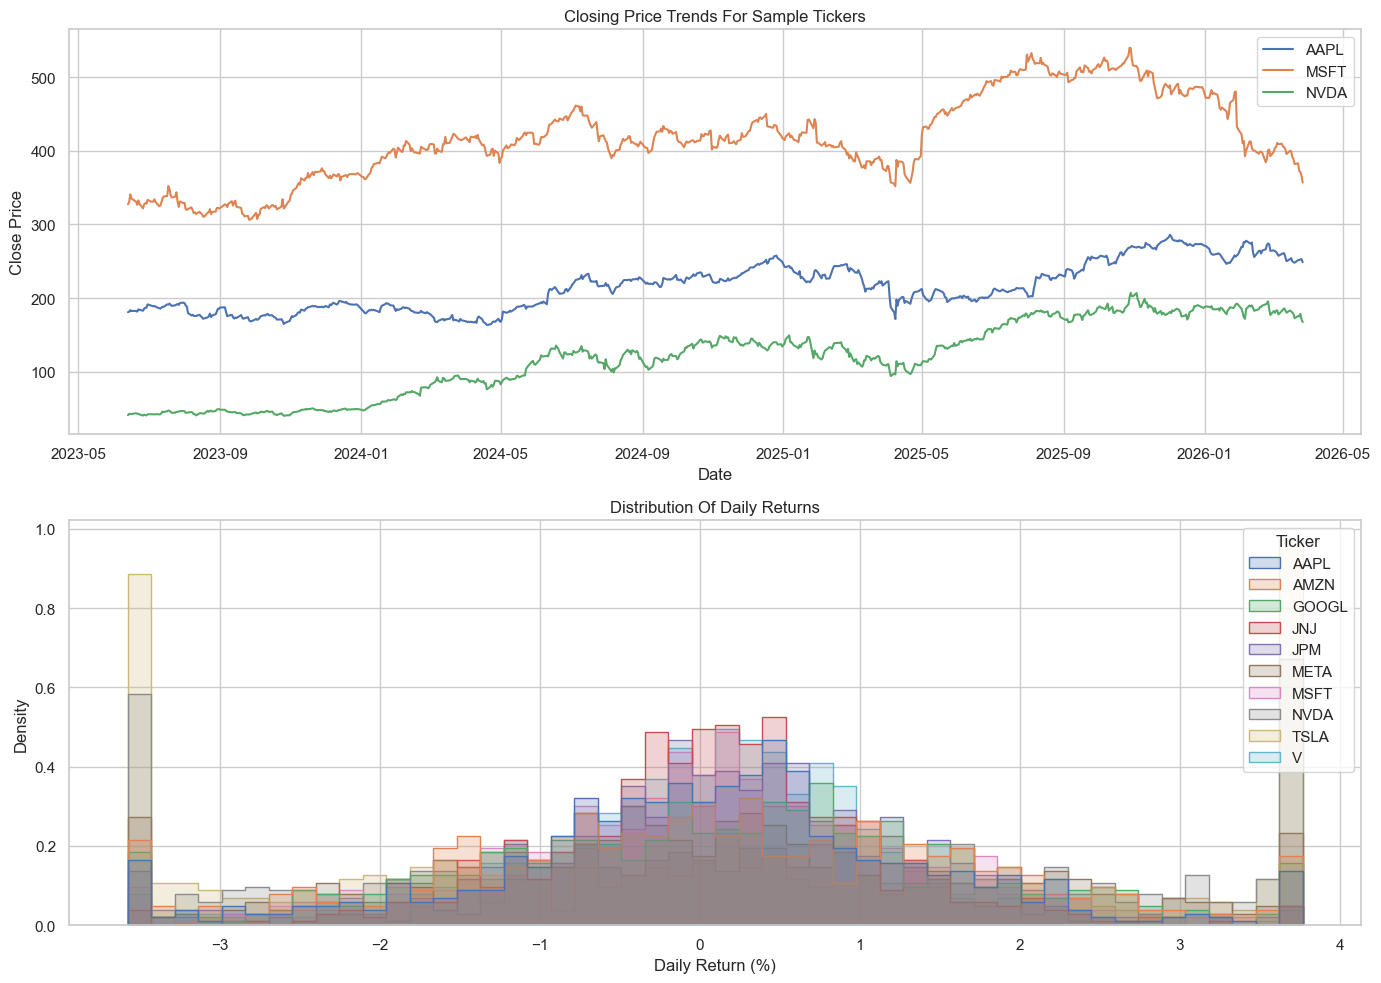

In [9]:

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

sample_tickers = ['AAPL', 'MSFT', 'NVDA']
for ticker in sample_tickers:
    ticker_frame = capped_data[capped_data['Ticker'] == ticker]
    axes[0].plot(ticker_frame['Date'], ticker_frame['Close'], label=ticker)

axes[0].set_title('Closing Price Trends For Sample Tickers')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Close Price')
axes[0].legend()

sns.histplot(data=capped_data, x='Daily_Return', hue='Ticker', bins=50, ax=axes[1], element='step', stat='density', common_norm=False)
axes[1].set_title('Distribution Of Daily Returns')
axes[1].set_xlabel('Daily Return (%)')

plt.tight_layout()
plt.show()


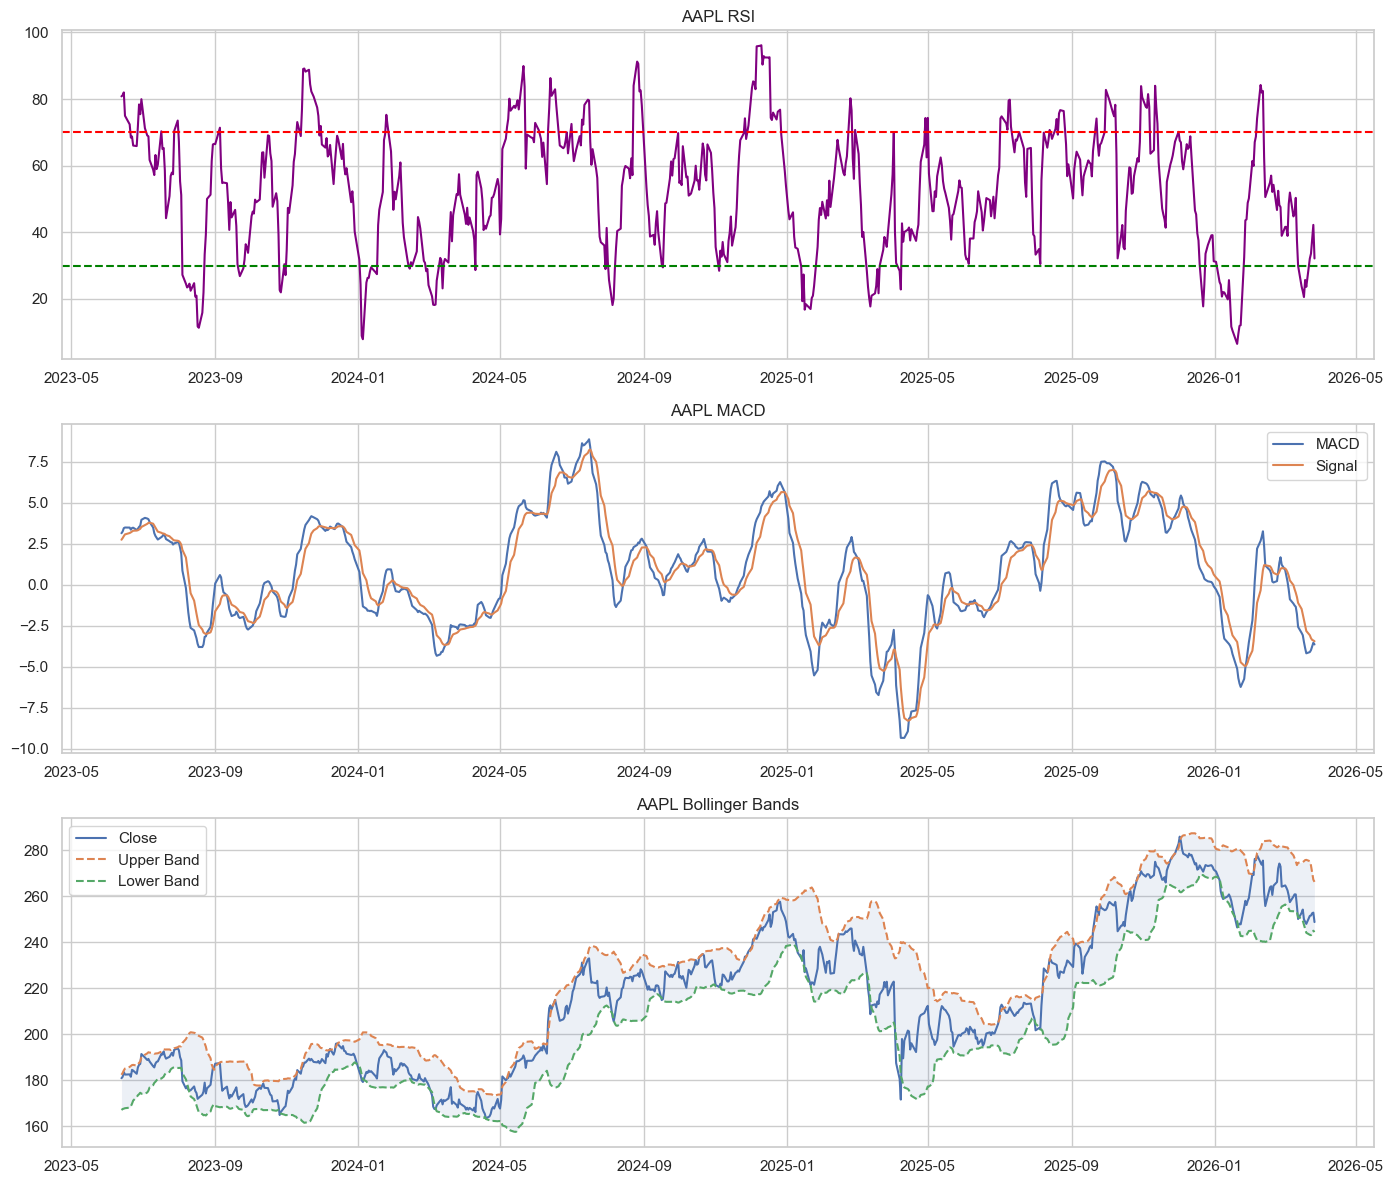

In [10]:

aapl = capped_data[capped_data['Ticker'] == 'AAPL'].copy()
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(aapl['Date'], aapl['RSI'], color='purple')
axes[0].axhline(70, linestyle='--', color='red')
axes[0].axhline(30, linestyle='--', color='green')
axes[0].set_title('AAPL RSI')

axes[1].plot(aapl['Date'], aapl['MACD'], label='MACD')
axes[1].plot(aapl['Date'], aapl['MACD_Signal'], label='Signal')
axes[1].legend()
axes[1].set_title('AAPL MACD')

axes[2].plot(aapl['Date'], aapl['Close'], label='Close')
axes[2].plot(aapl['Date'], aapl['BB_Upper'], linestyle='--', label='Upper Band')
axes[2].plot(aapl['Date'], aapl['BB_Lower'], linestyle='--', label='Lower Band')
axes[2].fill_between(aapl['Date'], aapl['BB_Lower'], aapl['BB_Upper'], alpha=0.1)
axes[2].legend()
axes[2].set_title('AAPL Bollinger Bands')

plt.tight_layout()
plt.show()


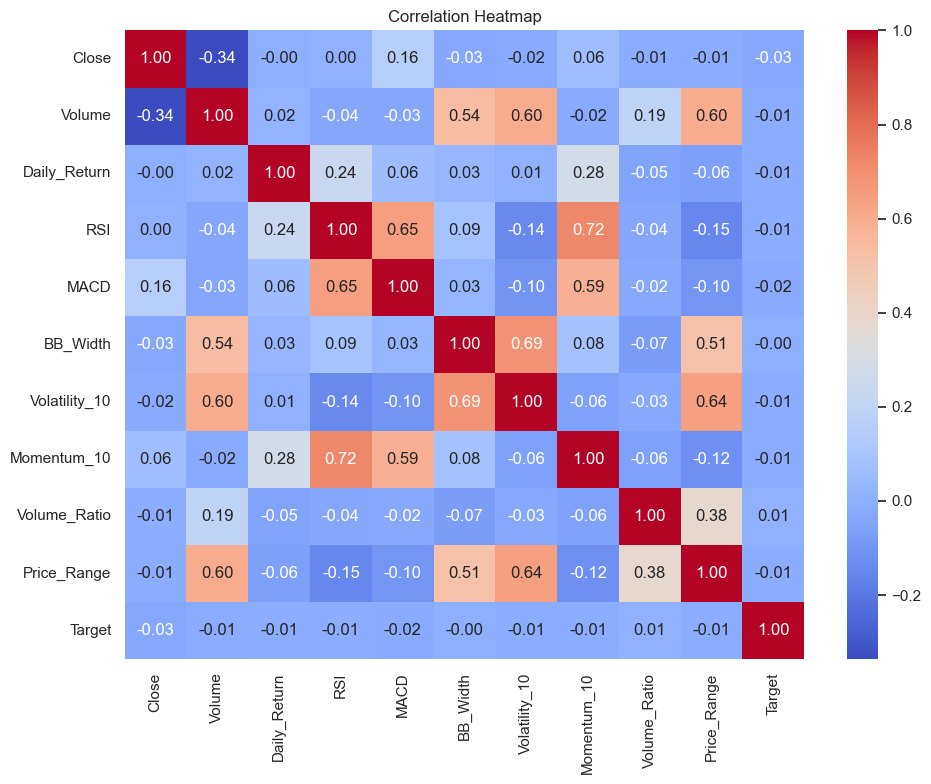

In [11]:

correlation_features = [
    'Close', 'Volume', 'Daily_Return', 'RSI', 'MACD', 'BB_Width',
    'Volatility_10', 'Momentum_10', 'Volume_Ratio', 'Price_Range', 'Target'
]
correlation_matrix = capped_data[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [12]:

print('Key findings summary')
print('=' * 60)
print('Total rows used for modeling:', len(capped_data))
print('Average closing price:', round(capped_data['Close'].mean(), 2))
print('Average daily return:', round(capped_data['Daily_Return'].mean(), 4))
print('Average RSI:', round(capped_data['RSI'].mean(), 2))
print('Target up-move ratio:', round(capped_data['Target'].mean(), 4))
print('Most volatile ticker:')
volatility_summary = capped_data.groupby('Ticker')['Daily_Return'].std().sort_values(ascending=False)
display(volatility_summary.to_frame('Return Std Dev'))


Key findings summary
Total rows used for modeling: 7000
Average closing price: 259.15
Average daily return: 0.091
Average RSI: 54.36
Target up-move ratio: 0.5384
Most volatile ticker:


,Return Std Dev
Ticker,
TSLA,2.469621
NVDA,2.227449
META,1.761109
AMZN,1.661268
GOOGL,1.571841
AAPL,1.397433
MSFT,1.313104
JPM,1.250476
V,1.100399



## Step 4: Feature Selection


In [13]:

selected_features, feature_importance, dropped_correlated = select_features(encoded_data)

print('Selected features:', len(selected_features))
print(selected_features)
print('\nDropped by correlation pruning:')
print(dropped_correlated if dropped_correlated else 'None')

feature_importance.head(15)


Selected features: 13
['Volume_Ratio', 'Gap_Open', 'RSI', 'Daily_Return', 'Momentum_5', 'Volatility_20', 'Momentum_10', 'Volatility_10', 'HL_Spread', 'BB_Width', 'MACD_Signal', 'Volume_MA_10', 'BB_Lower']

Dropped by correlation pruning:
['BB_Upper', 'EMA_12', 'MACD', 'MA_10', 'MA_5', 'MA_50', 'Price_Range', 'Volume']


,Feature,Importance
0,Volume_Ratio,0.049592
1,Gap_Open,0.049509
2,RSI,0.047739
3,Daily_Return,0.047183
4,Momentum_5,0.046267
5,Volatility_20,0.044711
6,Momentum_10,0.044657
7,Volatility_10,0.044523
8,HL_Spread,0.043754
9,Price_Range,0.043417


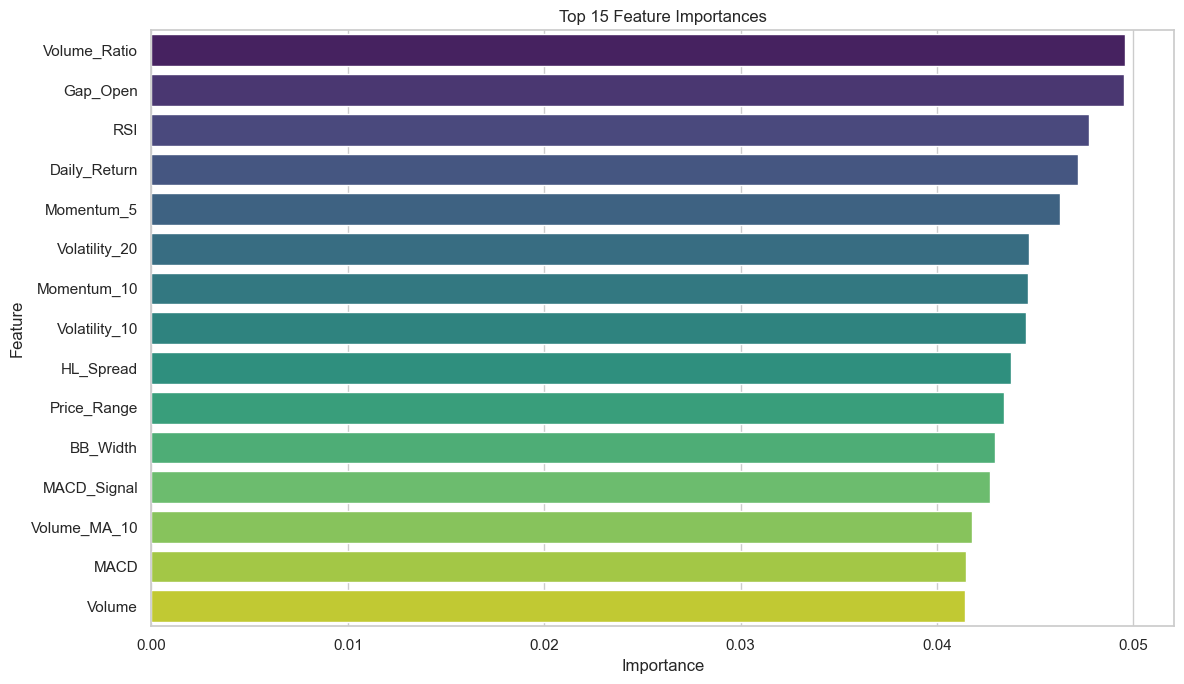

In [14]:

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()



## Step 5: Model Development


In [15]:

x_train, x_test, y_train, y_test, train_df, test_df = split_train_test_by_date(
    encoded_data,
    feature_cols=selected_features,
    test_size=0.20,
)

print('Training rows:', len(x_train))
print('Testing rows:', len(x_test))
print('Training date range:', train_df['Date'].min().date(), 'to', train_df['Date'].max().date())
print('Testing date range:', test_df['Date'].min().date(), 'to', test_df['Date'].max().date())


Training rows: 5600
Testing rows: 1400
Training date range: 2023-06-13 to 2025-09-05
Testing date range: 2025-09-08 to 2026-03-27


In [16]:

results_df, trained_models = compare_models(x_train, y_train, x_test, y_test)
results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Model
0,0.500714,0.507212,0.882845,0.644275,0.495656,Logistic Regression
1,0.506429,0.511404,0.813110,0.627894,0.496531,SVM
2,0.512857,0.515924,0.790795,0.624449,0.506180,Naive Bayes
3,0.516429,0.521186,0.686192,0.592414,0.525407,Random Forest
4,0.515714,0.521358,0.663877,0.584049,0.498525,Gradient Boosting
5,0.527857,0.533254,0.626220,0.576010,0.518556,K-Nearest Neighbors


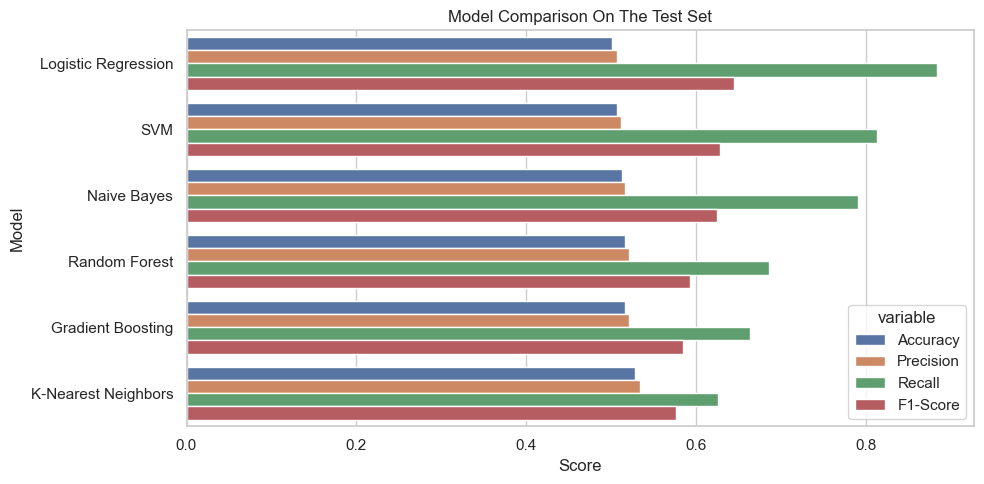

In [17]:

plt.figure(figsize=(10, 5))
plot_df = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
sns.barplot(data=plot_df, x='value', y='Model', hue='variable')
plt.title('Model Comparison On The Test Set')
plt.xlabel('Score')
plt.tight_layout()
plt.show()


Best baseline model: Logistic Regression
              precision    recall  f1-score   support

    Down (0)       0.45      0.10      0.16       683
      Up (1)       0.51      0.88      0.64       717

    accuracy                           0.50      1400
   macro avg       0.48      0.49      0.40      1400
weighted avg       0.48      0.50      0.41      1400



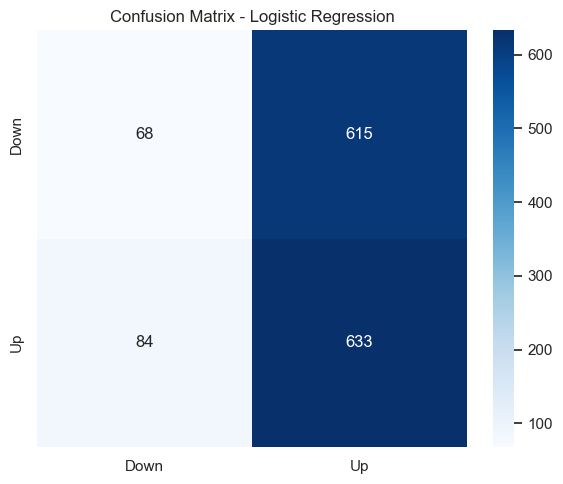

In [18]:

best_model_name = results_df.iloc[0]['Model']
base_bundle = trained_models[best_model_name]
base_model = base_bundle['model']
base_scaler = base_bundle['scaler']
base_pred = base_bundle['y_pred']
base_prob = base_bundle['y_prob']

print('Best baseline model:', best_model_name)
print(classification_report(y_test, base_pred, target_names=['Down (0)', 'Up (1)']))

cm = confusion_matrix(y_test, base_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()



## Step 6: Model Evaluation and Hyperparameter Tuning


In [19]:

cv_reference = train_df[['Date'] + selected_features + ['Target']].copy()
cv_splits = build_time_series_splits(cv_reference, n_splits=5)
cv_df = cross_validate_model(best_model_name, x_train, y_train, cv_splits)

print('Cross-validation results for the best baseline model:')
display(cv_df)
print('\nMean CV scores:')
display(cv_df.mean(numeric_only=True).to_frame('Mean Score'))


Cross-validation results for the best baseline model:


,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,0.516129,0.594203,0.530499,0.560547,0.499708
1,2,0.529032,0.549258,0.796477,0.650160,0.520795
2,3,0.548387,0.565114,0.894140,0.692533,0.495236
3,4,0.497849,0.497619,0.902808,0.641596,0.519103
4,5,0.522581,0.555874,0.743295,0.636066,0.485210



Mean CV scores:


,Mean Score
Fold,3.000000
Accuracy,0.522796
Precision,0.552413
Recall,0.773444
F1-Score,0.636180
ROC-AUC,0.504010


In [20]:

grid_search = tune_model(best_model_name, x_train, y_train, cv_splits)
print('Best parameters:')
print(grid_search.best_params_)
print('Best CV F1-score:', round(grid_search.best_score_, 4))


Best parameters:
{'model__C': 0.1, 'model__class_weight': None}
Best CV F1-score: 0.6374


Tuned model classification report:
              precision    recall  f1-score   support

    Down (0)       0.44      0.09      0.15       683
      Up (1)       0.51      0.89      0.65       717

    accuracy                           0.50      1400
   macro avg       0.47      0.49      0.40      1400
weighted avg       0.47      0.50      0.41      1400

Tuned ROC-AUC: 0.4954


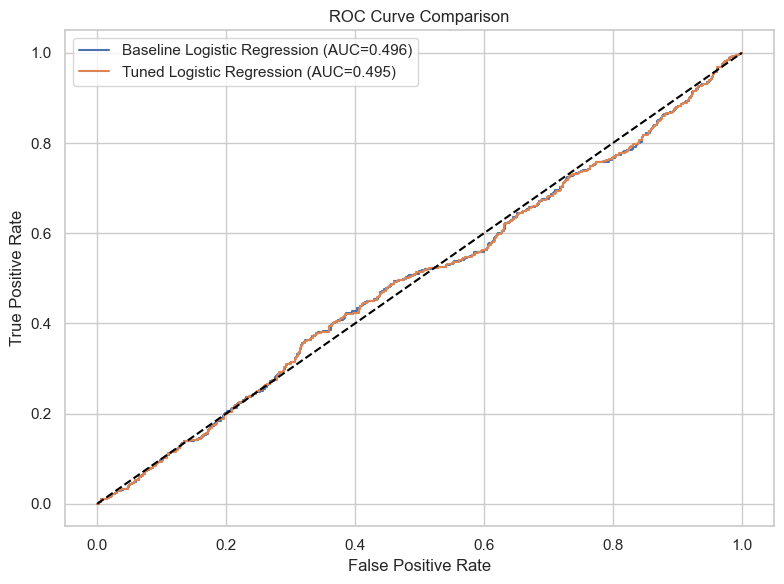

In [21]:

tuned_scaler = grid_search.best_estimator_.named_steps['scaler']
tuned_model = grid_search.best_estimator_.named_steps['model']
tuned_pred = tuned_model.predict(tuned_scaler.transform(x_test))
tuned_prob = tuned_model.predict_proba(tuned_scaler.transform(x_test))[:, 1]

print('Tuned model classification report:')
print(classification_report(y_test, tuned_pred, target_names=['Down (0)', 'Up (1)']))
print('Tuned ROC-AUC:', round(roc_auc_score(y_test, tuned_prob), 4))

fpr_base, tpr_base, _ = roc_curve(y_test, base_prob)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline {best_model_name} (AUC={roc_auc_score(y_test, base_prob):.3f})')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned {best_model_name} (AUC={roc_auc_score(y_test, tuned_prob):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()



## Step 7: Save Model For Deployment


In [22]:

base_metrics = evaluate_predictions(y_test, base_pred, base_prob)
tuned_metrics = evaluate_predictions(y_test, tuned_pred, tuned_prob)

if tuned_metrics['F1-Score'] >= base_metrics['F1-Score']:
    final_model = tuned_model
    final_scaler = tuned_scaler
    final_metrics = tuned_metrics
    final_model_name = f'Tuned {best_model_name}'
else:
    final_model = base_model
    final_scaler = base_scaler
    final_metrics = base_metrics
    final_model_name = best_model_name

model_info = {
    'project_title': 'Stock Market Price Movement Prediction',
    'model_name': final_model_name,
    'training_tickers': tickers,
    'feature_count': len(selected_features),
    'features': selected_features,
    'accuracy': float(final_metrics['Accuracy']),
    'precision': float(final_metrics['Precision']),
    'recall': float(final_metrics['Recall']),
    'f1_score': float(final_metrics['F1-Score']),
    'roc_auc': None if final_metrics['ROC-AUC'] is None else float(final_metrics['ROC-AUC']),
    'best_baseline_model': best_model_name,
    'test_rows': int(len(x_test)),
    'train_rows': int(len(x_train)),
    'trained_at': datetime.now().isoformat(timespec='seconds'),
    'top_feature_importance': feature_importance.head(10).to_dict(orient='records'),
    'dropped_correlated_features': dropped_correlated,
    'cross_validation': {
        'accuracy_mean': float(cv_df['Accuracy'].mean()),
        'precision_mean': float(cv_df['Precision'].mean()),
        'recall_mean': float(cv_df['Recall'].mean()),
        'f1_mean': float(cv_df['F1-Score'].mean()),
        'roc_auc_mean': float(cv_df['ROC-AUC'].mean()),
    },
    'grid_search_best_params': grid_search.best_params_,
}

save_artifacts(final_model, final_scaler, selected_features, model_info)

print('Final model saved successfully.')
print('Selected model:', final_model_name)
print('Final test metrics:')
for key, value in final_metrics.items():
    if value is None:
        print(f'  {key}: None')
    else:
        print(f'  {key}: {value:.4f}')


Final model saved successfully.
Selected model: Tuned Logistic Regression
Final test metrics:
  Accuracy: 0.5000
  Precision: 0.5068
  Recall: 0.8870
  F1-Score: 0.6450
  ROC-AUC: 0.4954



## Step 8: Streamlit Deployment On Localhost

The project includes a Streamlit application in `app.py` that uses the saved model artifacts generated by this notebook.

Run the app with:

```bash
streamlit run app.py
```


In [23]:

print('Notebook workflow complete.')
print('To launch the web application, run: streamlit run app.py')


Notebook workflow complete.
To launch the web application, run: streamlit run app.py
